## 🔵 Evaluating K-Means Clustering

---

## 🎯 Objectives

After completing this lab, I will be able to:

- 🔵 Implement and evaluate **K-Means clustering** on synthetic data  
- 📊 Interpret clustering evaluation metrics and visualizations  
- 🧠 Compare clustering results against known classes  

---

## 📚 Introduction

In this lab, I explore clustering performance using controlled, synthetic datasets.

---

## 🛠️ What is covered

- 🧪 Generate **synthetic data** for controlled experiments  
- 🔵 Build and compare multiple **K-Means models**  
- 📊 Evaluate clustering quality using different metrics  
- 🔍 Analyze how well clusters match known underlying classes  

---

## 🧠 Key Idea

Clustering is inherently **subjective**:

- 📊 There is no single “correct” answer  
- ⚖️ Different metrics may suggest different optimal solutions  
- 🔍 Visual interpretation plays a crucial role  

---

## 🚀 Goal

The focus is on developing intuition for:

- 📈 Identifying meaningful clusters  
- ⚖️ Evaluating clustering quality  
- 🧠 Understanding the strengths and limitations of K-Means  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.datasets import make_classification
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from scipy.spatial import Voronoi, voronoi_plot_2d
from matplotlib.patches import Patch
from matplotlib import cm

## 📊 Clustering Evaluation Function

A function is defined to evaluate clustering models using:

- 📈 **Silhouette Score** (higher is better)  
- 📉 **Davies-Bouldin Index** (lower is better)  
- 📊 **Silhouette Plot** for visual assessment of cluster quality

In [2]:
def evaluate_clustering(X, labels, n_clusters, ax=None, title_suffix=''):
    """
    Evaluate a clustering model using silhouette scores and the Davies-Bouldin index.
    
    Parameters:
    X (ndarray): Feature matrix.
    labels (array-like): Cluster labels assigned to each sample.
    n_clusters (int): The number of clusters in the model.
    ax: The subplot axes to plot on.
    title_suffix (str): Optional suffix for plot titlec
    
    Returns:
    None: Displays silhoutte scores and a silhouette plot.
    """
    if ax is None:
        ax = plt.gca()  # Get the current axis if none is provided
    
    # Calculate silhouette scores
    silhouette_avg = silhouette_score(X, labels)
    sample_silhouette_values = silhouette_samples(X, labels)

    # Plot silhouette analysis on the provided axis
    unique_labels = np.unique(labels)
    colormap = cm.tab10
    color_dict = {label: colormap(float(label) / n_clusters) for label in unique_labels}
    y_lower = 10
    for i in unique_labels:
        ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        color = color_dict[i]
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                         0, ith_cluster_silhouette_values,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10
    
    ax.set_title(f'Silhouette Score for {title_suffix} \n' + 
                 f'Average Silhouette: {silhouette_avg:.2f}')
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_ylabel('Cluster')
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_xlim([-0.25, 1])  # Set the x-axis range to [0, 1]

    ax.set_yticks([])

## 🧪 Create Synthetic Data (4 Blobs)

Synthetic data is generated using four slightly overlapping clusters (blobs) to experiment with K-Means clustering.

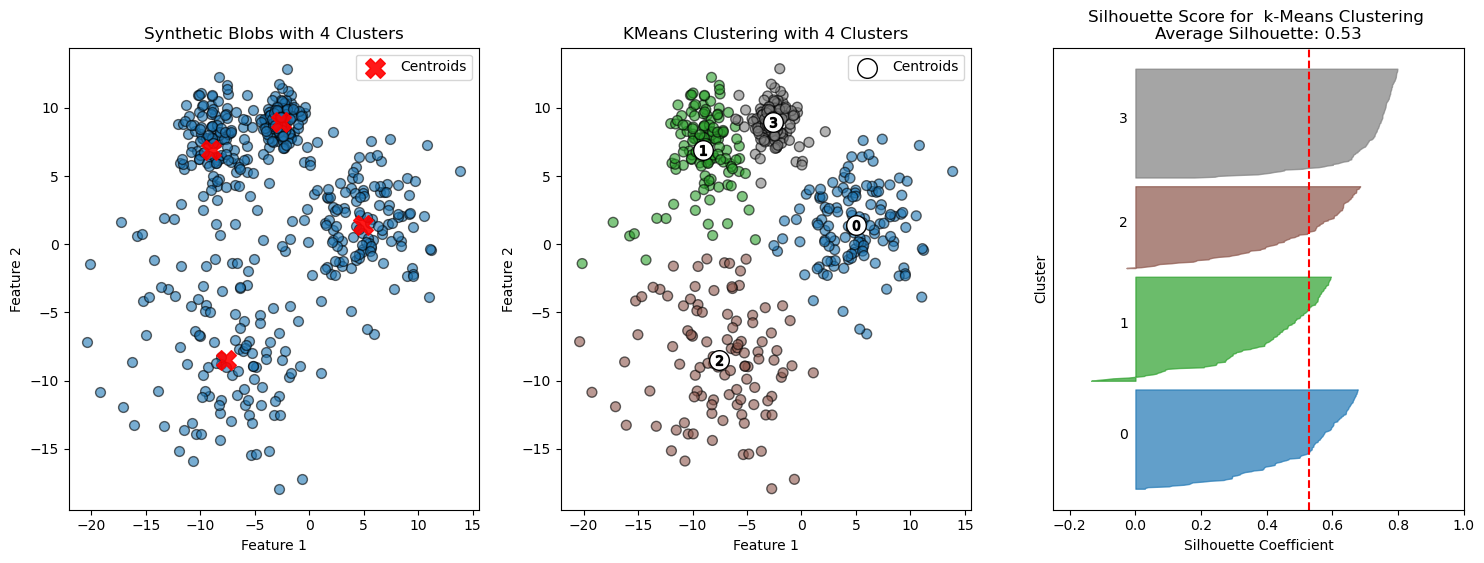

In [3]:
# Generate synthetic data with 4 clusters
X, y = make_blobs(n_samples=500, n_features=2, centers=4, cluster_std=[1.0, 3, 5, 2], random_state=42)

# Apply KMeans clustering
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
y_kmeans = kmeans.fit_predict(X)

colormap = cm.tab10

# Plot the blobs
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.scatter(X[:, 0], X[:, 1], s=50, alpha=0.6, edgecolor='k')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', alpha=0.9, label='Centroids')
plt.title(f'Synthetic Blobs with {n_clusters} Clusters')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

# Plot the clustering result
# Create colors based on the predicted labels
colors = colormap(y_kmeans.astype(float) / n_clusters)

plt.subplot(1, 3, 2)
plt.scatter(X[:, 0], X[:, 1], c=colors, s=50, alpha=0.6, edgecolor='k')

# Label the clusters
centers = kmeans.cluster_centers_
# Draw white circles at cluster centers
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="o",
    c="white",
    alpha=1,
    s=200,
    edgecolor="k",
    label='Centroids'
)
# Label the custer number
for i, c in enumerate(centers):
    plt.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

plt.title(f'KMeans Clustering with {n_clusters} Clusters')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

# Evaluate the clustering
plt.subplot(1, 3, 3)
evaluate_clustering(X, y_kmeans, n_clusters, title_suffix=' k-Means Clustering')
plt.show()

## 📊 Understanding the Silhouette Plot

Each point in a silhouette plot has a score ranging from **-1 to 1**:

- 📈 **High score (close to 1)** → the point is well matched to its own cluster and far from others  
- ⚖️ **Score near 0** → the point lies close to the boundary between clusters  
- ❌ **Negative score** → the point may be assigned to the wrong cluster  

A deeper analysis of the silhouette plot helps assess cluster quality and separation.

---

## 🧠 Interpretation of Results

The clustering result appears quite plausible, especially since the data was generated with **four underlying blobs**.

However, in practical scenarios:

- ❗ The true number of clusters is usually **unknown**  
- 🔍 Clustering evaluation relies on metrics and visual inspection rather than ground truth  

## 🔁 Cluster Stability in K-Means

Cluster stability examines how results change when K-Means is initialized with different centroid seeds.

---

## 📊 Key Concept: Inertia

- 📉 **Inertia** measures cluster compactness  
- 📐 Defined as the **sum of squared distances** between each point and its assigned centroid  
- ✅ Lower inertia → more compact clusters  

⚠️ However:
- Inertia **always decreases** as the number of clusters increases  
- It should be interpreted alongside other metrics (e.g., silhouette score)

---

## 🔍 Evaluating Stability

To assess stability:

- 🔁 Run K-Means multiple times with different initial centroid seeds  
- 🎲 Avoid fixing `random_state`  
- 📊 Compare inertia values across runs  

---

## 🧠 Interpretation

- ✅ **Consistent inertia across runs**  
  → Stable clustering solution  
  → Less sensitive to initialization  

- ⚠️ **High variability in inertia**  
  → Unstable clustering  
  → Results depend heavily on initial centroid placement  

---

## 🧾 Conclusion

Stable clustering indicates that K-Means consistently finds similar solutions, increasing confidence in the results. Unstable outcomes suggest the need for further tuning or alternative approaches.

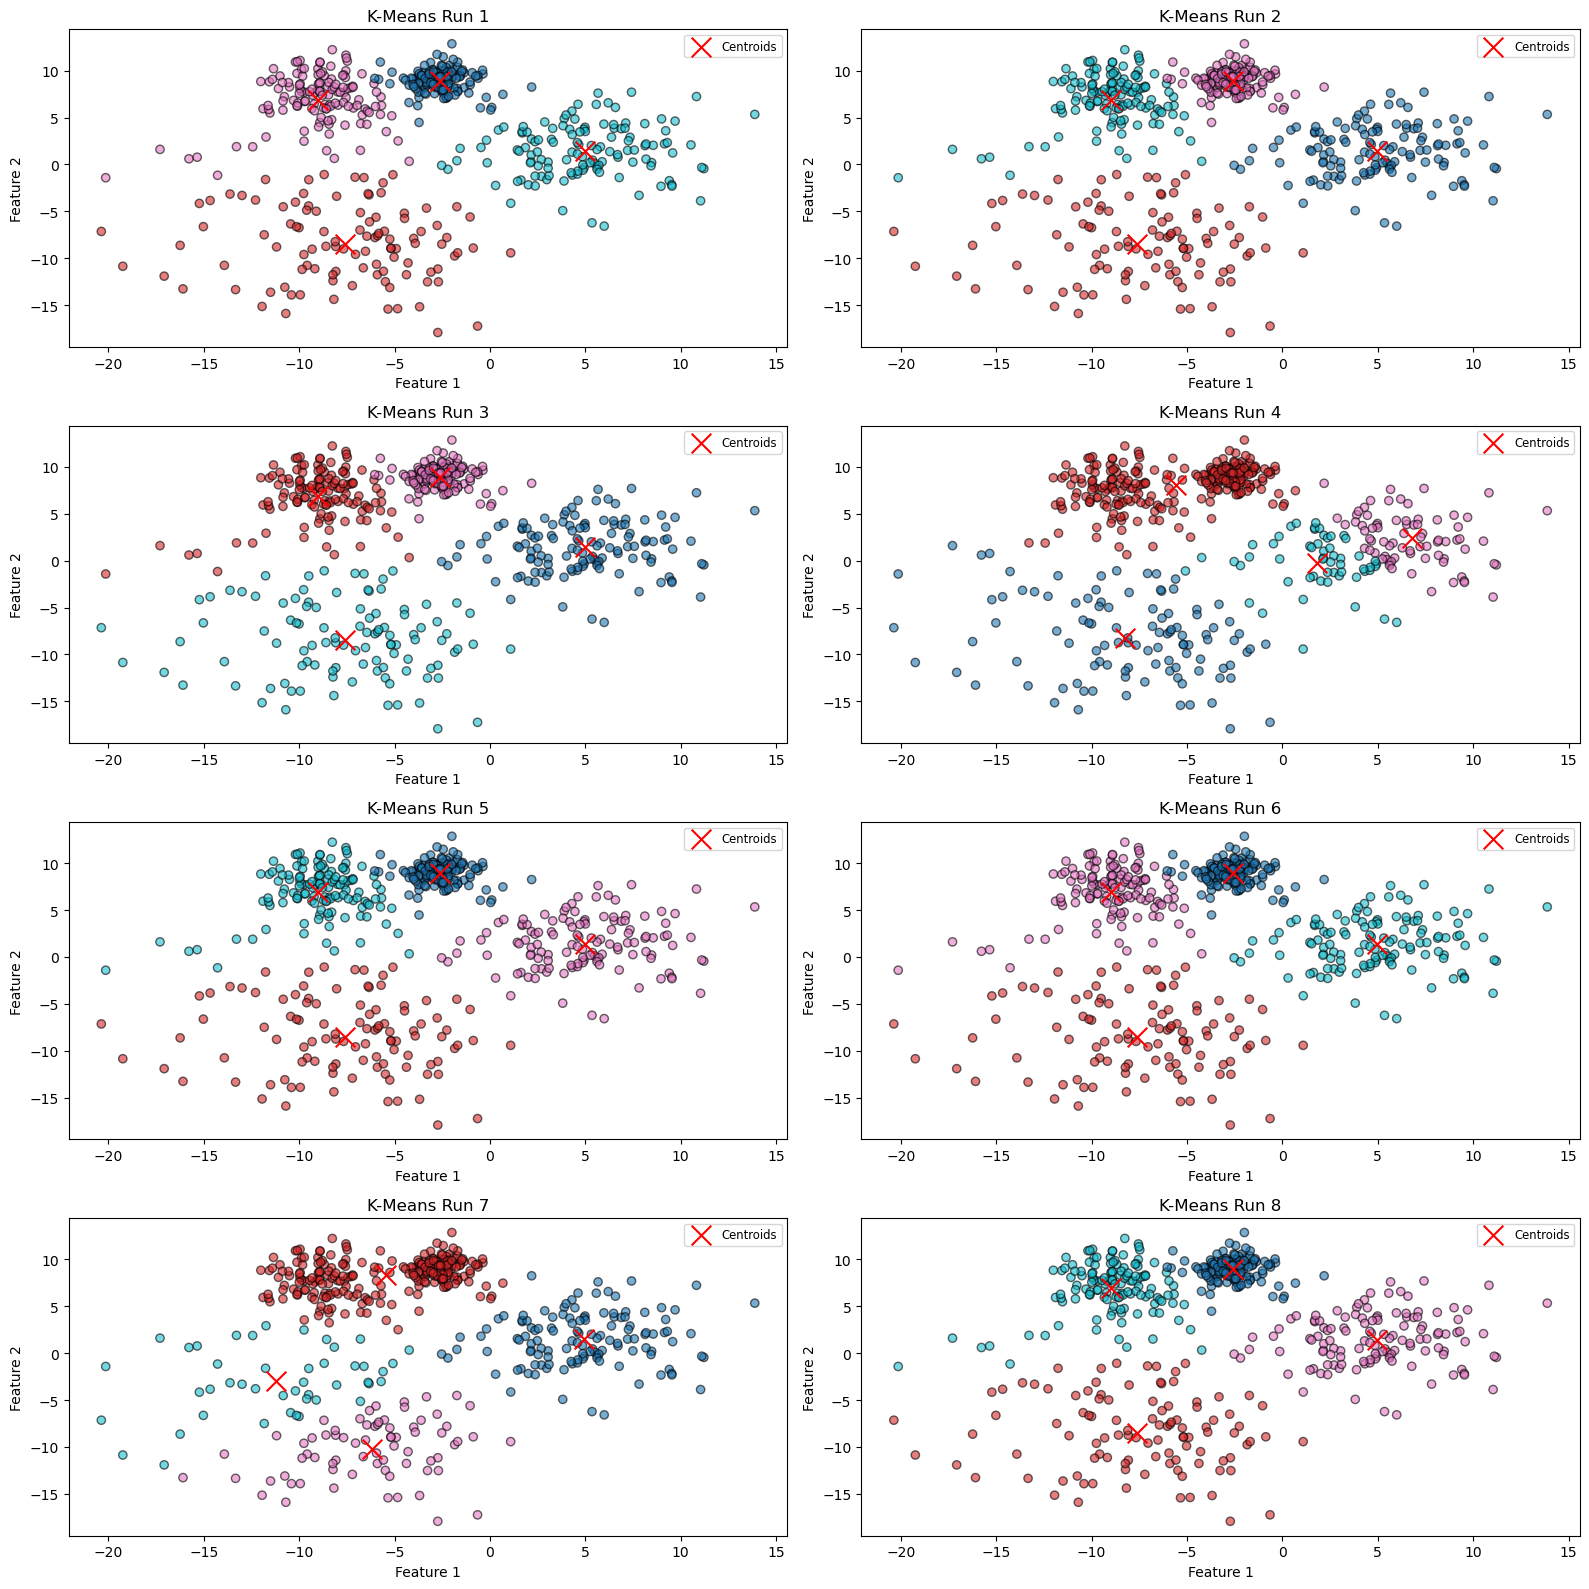

Run 1: Inertia=7633.51
Run 2: Inertia=7633.51
Run 3: Inertia=7633.51
Run 4: Inertia=9623.96
Run 5: Inertia=7633.51
Run 6: Inertia=7633.51
Run 7: Inertia=8556.71
Run 8: Inertia=7633.51


In [4]:
# Number of runs for k-means with different random states
n_runs = 8
inertia_values = []

# Calculate number of rows and columns needed for subplots
n_cols = 2 # Number of columns
n_rows = -(-n_runs // n_cols) # Ceil division to determine rows
plt.figure(figsize=(16, 16)) # Adjust the figure size for better visualization

# Run K-Means multiple times with different random states
for i in range(n_runs):
    kmeans = KMeans(n_clusters=4, random_state=None)  # Use the default `n_init`
    kmeans.fit(X)
    inertia_values.append(kmeans.inertia_)

    # Plot the clustering result
    plt.subplot(n_rows, n_cols, i + 1)
    plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='tab10', alpha=0.6, edgecolor='k')
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', s=200, marker='x', label='Centroids')
    plt.title(f'K-Means Run {i + 1}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend(loc='upper right', fontsize='small')

plt.tight_layout()
plt.show()

# Print inertia values
for i, inertia in enumerate(inertia_values, start=1):
    print(f'Run {i}: Inertia={inertia:.2f}')

## 🧠 Exercise 1: Interpretation of Cluster Stability

The results show that **cluster assignments vary across runs** when different initial centroid seeds are used.

---

## 📊 Observations

- 🔁 Cluster labels change between runs  
- 📉 Inertia values are inconsistent  
- 🎲 Results depend on initial centroid placement  

---

## 🧠 Interpretation

- ⚠️ The clustering is **sensitive to initialization**  
- 📊 Variability in inertia indicates **lack of stability**  
- ❗ This suggests the solution may not be fully reliable  

---

## 🧾 Conclusion

The inconsistency in both cluster assignments and inertia values indicates that the K-Means model is **not stable**, and results may vary depending on initialization. Further tuning (e.g., increasing `n_init`) or alternative approaches may be needed for more reliable clustering.

## 🔢 Number of Clusters (K)

As the number of clusters increases:

- 📉 **Inertia** decreases (clusters become more compact)  
- 📉 **Davies-Bouldin Index** generally decreases (better separation)  
- 📈 **Silhouette Score** may increase up to an optimal point, then decrease  

---

## 🧠 Interpretation

- 📊 Increasing K improves fit but may lead to **over-segmentation**  
- 📉 The **elbow point** in inertia helps identify diminishing returns  
- 📈 The **peak silhouette score** suggests the most balanced clustering  

---

## 🧾 Conclusion

Yes, this analysis can guide the choice of an optimal number of clusters by combining:

- 📊 Metric trends  
- 📈 Visual inspection  
- 🧠 Practical interpretation  

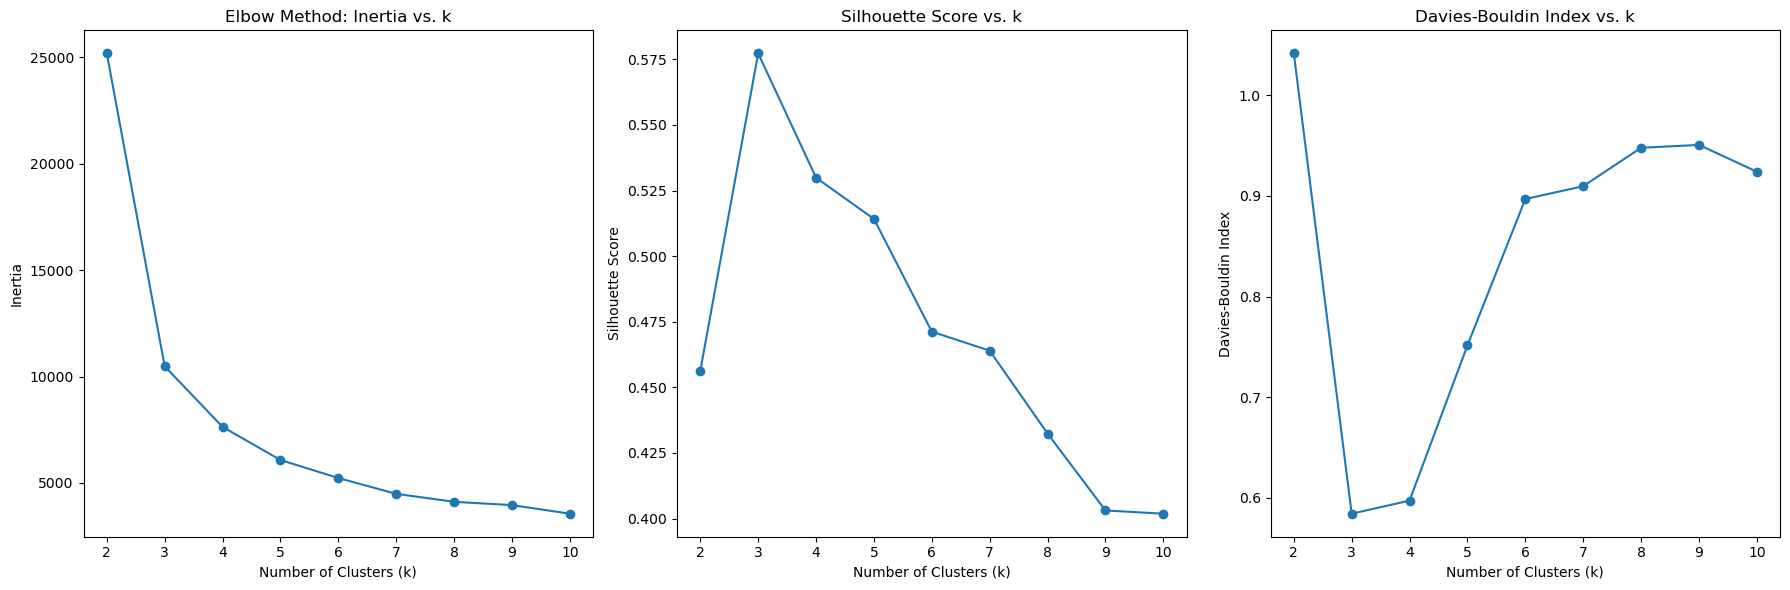

In [5]:
# Range of k values to test
k_values = range(2, 11)

# Store performance metrics
inertia_values = []
silhouette_scores = []
davies_bouldin_indices = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    y_kmeans = kmeans.fit_predict(X)
    
    # Calculate and store metrics
    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, y_kmeans))
    davies_bouldin_indices.append(davies_bouldin_score(X, y_kmeans))

# Plot the inertia values (Elbow Method)
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.plot(k_values, inertia_values, marker='o')
plt.title('Elbow Method: Inertia vs. k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

# Plot silhouette scores
plt.subplot(1, 3, 2)
plt.plot(k_values, silhouette_scores, marker='o')
plt.title('Silhouette Score vs. k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

# Plot Davies-Bouldin Index
plt.subplot(1, 3, 3)
plt.plot(k_values, davies_bouldin_indices, marker='o')
plt.title('Davies-Bouldin Index vs. k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Davies-Bouldin Index')

plt.tight_layout()
plt.show()

## 🧠 Exercise 2: Interpretation of Results

- 📉 The **inertia plot** (elbow method) suggests an optimal number of clusters around **3 or 4**, where the curve begins to level off and additional clusters yield diminishing returns  

- 📈 The **silhouette score** reaches a clear peak at **k = 3**, indicating well-separated and cohesive clusters  

- 📉 The **Davies-Bouldin index** is lowest between **k = 3 and k = 4**, suggesting good cluster separation in this range  

---

## 🧾 Conclusion

Overall, these metrics point toward **k = 3** as a strong candidate for the optimal number of clusters.  

However, it is known that the true number of clusters is **4**, highlighting an important limitation:

- 📊 Clustering metrics may not always recover the true underlying structure  
- 🧠 Results should be interpreted alongside domain knowledge and visual inspection  

## 📊 Exercise 3: Visualizing Clusters for K = 3, 4, and 5

The synthetic blobs are plotted alongside K-Means clustering results for different values of **K** to compare how cluster structure changes.

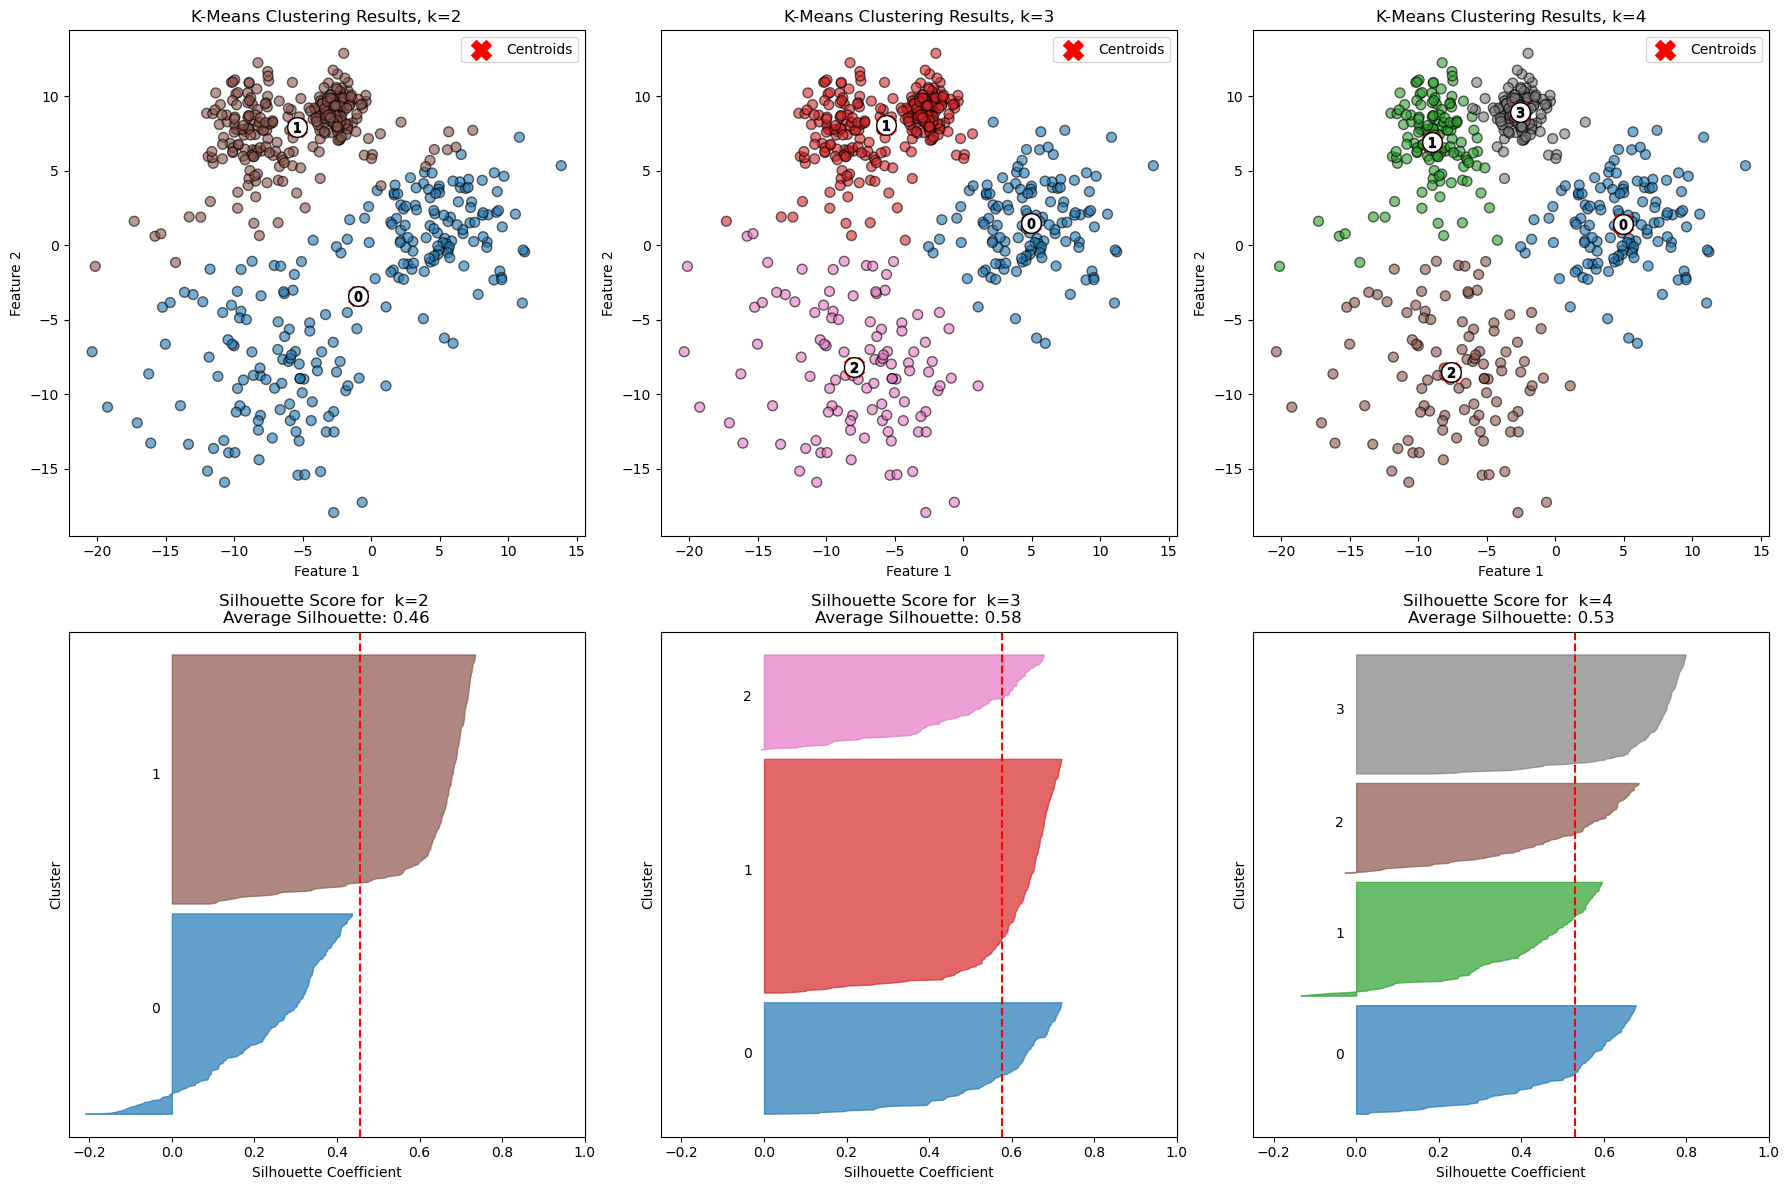

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

plt.figure(figsize=(18, 12))
colormap = cm.tab10

for i, k in enumerate([2, 3, 4]):
    # Fit KMeans and predict the labels
    kmeans = KMeans(n_clusters=k, random_state=42)  
    y_kmeans = kmeans.fit_predict(X)

    # Create colors based on the predicted labels
    colors = colormap(y_kmeans.astype(float) / k)

    # Scatter plot for each k in the first row
    ax1 = plt.subplot(2, 3, i + 1)
    ax1.scatter(X[:, 0], X[:, 1], c=colors, s=50, alpha=0.6, edgecolor='k')
    ax1.scatter(kmeans.cluster_centers_[:, 0], 
                kmeans.cluster_centers_[:, 1], 
                c='red', s=200, marker='X', label='Centroids')

    # Draw white circles at cluster centers
    centers = kmeans.cluster_centers_
    ax1.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k"
    )

    # Label clusters with numbers
    for idx, c in enumerate(centers):
        ax1.scatter(c[0], c[1], marker=f"${idx}$", alpha=1, s=50, edgecolor="k")

    ax1.set_title(f'K-Means Clustering Results, k={k}')
    ax1.set_xlabel('Feature 1')
    ax1.set_ylabel('Feature 2')
    ax1.legend()

    # Silhouette plot for each k in the second row
    ax2 = plt.subplot(2, 3, i + 4)
    evaluate_clustering(X, y_kmeans, k, ax=ax2, title_suffix=f' k={k}')

plt.tight_layout()
plt.show()


## 🧠 Exercise 4: Consistency with Evaluation Metrics

The clustering results are generally **consistent with the earlier metric-based analysis**, but they also highlight the inherent ambiguity in selecting the optimal number of clusters.

---

## 📊 Comparison with Previous Results

- 📉 The **evaluation metrics (silhouette score, Davies-Bouldin index, inertia)** suggested:
  - Strong support for **k = 3**
  - Reasonable performance also at **k = 4**

- 🔍 The visual clustering results show:
  - For **k = 3**:
    - Some regions with different densities are merged
    - Less separation between natural groups  
  - For **k = 4**:
    - A clearer split of dense and sparse regions
    - Better alignment with the true underlying structure  

---

## 📈 Silhouette Plot Interpretation

- 📊 For **k = 4**, silhouette blocks are relatively uniform  
  → suggests balanced cluster sizes  
- ⚠️ However, several points remain close to decision boundaries  
  → indicates overlapping or ambiguous clusters  

- 📊 For **k = 3**, silhouette scores appear more consistent overall  
  → better separation according to the metric  

---

## 🧠 Conclusion

- 📊 Metrics alone tend to favor **k = 3**  
- 👁️ Visual inspection suggests **k = 4** better captures the true structure  
- ⚖️ The optimal number of clusters is not definitive and depends on the balance between:
  - Statistical metrics  
  - Visual interpretation  
  - Domain understanding  

---

## ⚠️ Limitations of K-Means – Shape Sensitivity

K-Means is not suitable for all types of datasets, especially when cluster shapes are not spherical.

---

## 🚫 When K-Means is not appropriate

K-Means performs poorly when:

- 🌙 Clusters are **non-spherical or curved** (e.g. moons, rings)  
- 📏 Cluster sizes or densities are very different  
- 🔗 Data contains **overlapping or elongated structures**  
- 📊 Clusters are not separable using simple Euclidean distance  

---

## 🧠 Why this happens

- 🔵 K-Means assumes clusters are:
  - Convex  
  - Roughly circular (isotropic)  
  - Similar in size  

- 📉 It relies on **distance to centroids**, which fails for complex shapes  

---

## 🔄 Better alternatives

Depending on the structure of the data, better methods include:

- 🌲 **DBSCAN / HDBSCAN** → density-based clustering, good for irregular shapes  
- 🧭 **Spectral Clustering** → captures non-linear cluster boundaries  
- 🔗 **Agglomerative Clustering** → hierarchical structure, flexible shapes  

---

## 🧾 Conclusion

K-Means works well for simple, well-separated clusters, but struggles with complex geometries. In such cases, density-based or graph-based methods are more appropriate.

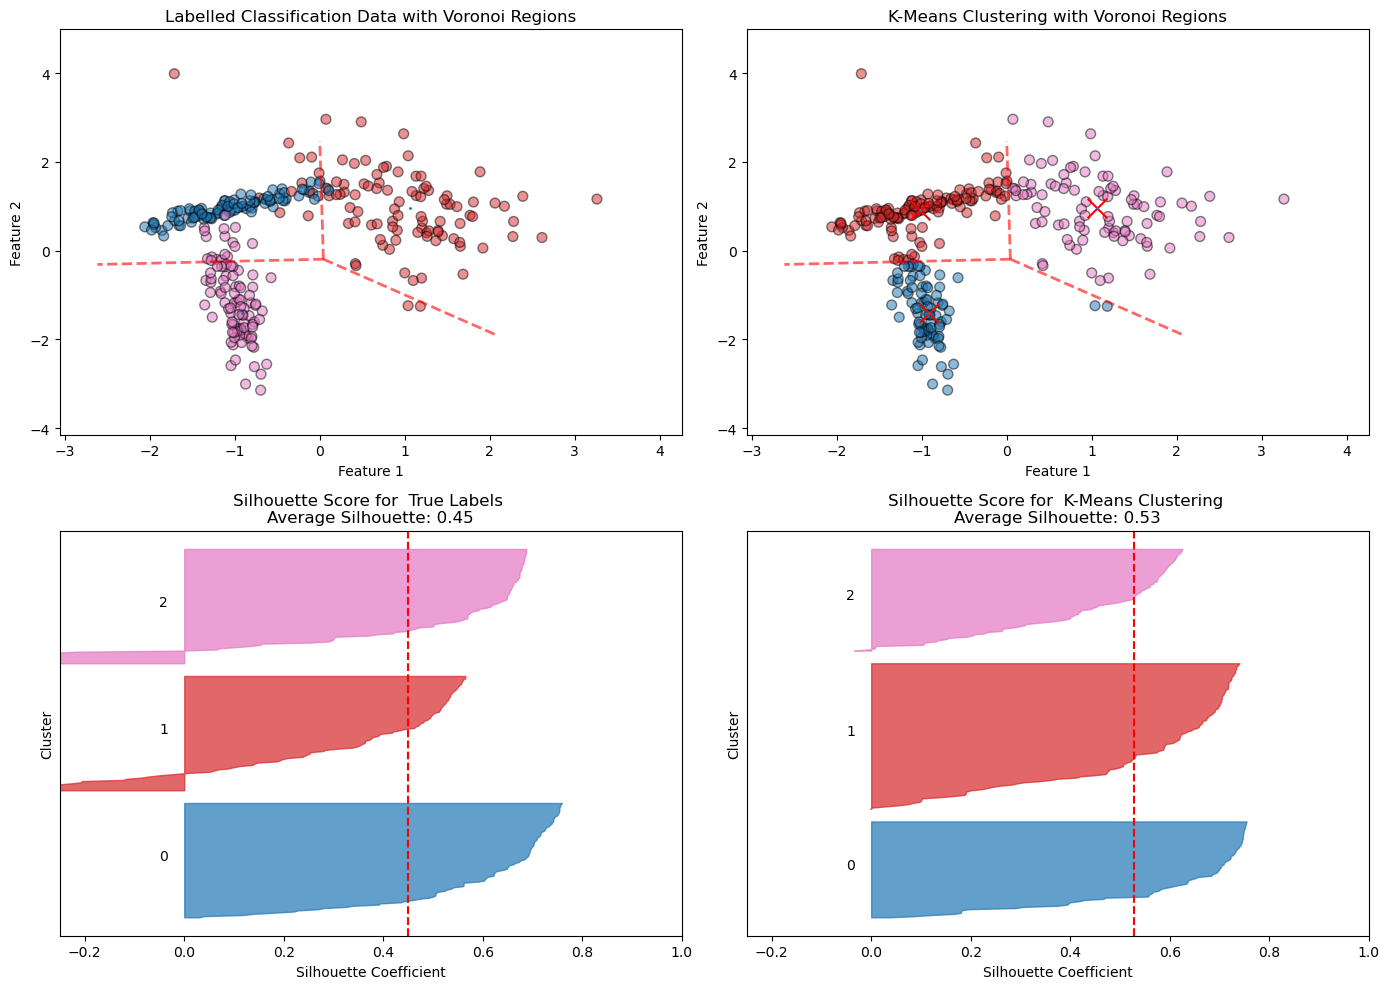

In [7]:
# Generate synthetic classification data
X, y_true = make_classification(n_samples=300, n_features=2, n_informative=2, n_redundant=0,
                                n_clusters_per_class=1, n_classes=3, random_state=42)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

# Compute the Voronoi diagram
vor = Voronoi(centroids)

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Get consistent axis limits for all scatter plots
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

# Plot the true labels with Voronoi regions
colormap = cm.tab10
colors_true = colormap(y_true.astype(float) / 3)
axes[0, 0].scatter(X[:, 0], X[:, 1], c=colors_true, s=50, alpha=0.5, ec='k')
voronoi_plot_2d(vor, ax=axes[0, 0], show_vertices=False, line_colors='red', line_width=2, line_alpha=0.6, point_size=2)
axes[0, 0].set_title('Labelled Classification Data with Voronoi Regions')
axes[0, 0].set_xlabel('Feature 1')
axes[0, 0].set_ylabel('Feature 2')
axes[0, 0].set_xlim(x_min, x_max)
axes[0, 0].set_ylim(y_min, y_max)

# Call evaluate_clustering for true labels
evaluate_clustering(X, y_true, n_clusters=3, ax=axes[1, 0], title_suffix=' True Labels')

# Plot K-Means clustering results with Voronoi regions
colors_kmeans = colormap(y_kmeans.astype(float) / 3)
axes[0, 1].scatter(X[:, 0], X[:, 1], c=colors_kmeans, s=50, alpha=0.5, ec='k')
axes[0, 1].scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='x', label='Centroids')
voronoi_plot_2d(vor, ax=axes[0, 1], show_vertices=False, line_colors='red', line_width=2, line_alpha=0.6, point_size=2)

axes[0, 1].set_title('K-Means Clustering with Voronoi Regions')
axes[0, 1].set_xlabel('Feature 1')
axes[0, 1].set_ylabel('Feature 2')
axes[0, 1].set_xlim(x_min, x_max)
axes[0, 1].set_ylim(y_min, y_max)

# Call evaluate_clustering for K-Means labels
evaluate_clustering(X, y_kmeans, n_clusters=3, ax=axes[1, 1], title_suffix=' K-Means Clustering')

# Adjust layout and show plot
plt.tight_layout()
plt.show()


## 🧠 Exercise 5: Interpretation of Results

K-Means performs reasonably well in identifying **three clusters** that broadly align with the true class labels.

---

## 📊 What works well

- 🔵 The algorithm successfully separates the data into **3 main groups**  
- 📈 Overall clustering structure is visually consistent with the dataset  
- 📊 High-level grouping is correctly identified  

---

## ⚠️ Key limitations observed

- 🧠 K-Means struggles with **non-spherical, elongated cluster shapes**  
- 📉 It fails to fully capture the **linear structure** of the purple and green classes  
- 🔗 The method does not account for **density variations** within clusters  

---

## 📐 Voronoi boundary effect

- 📍 Cluster separation is based on **Voronoi regions**  
- ➗ This creates **linear decision boundaries** between centroids  
- ⚠️ As a result, points near boundaries are often misclassified  
- 🧪 Some purple and green points fall into incorrect clusters  

---

## 📊 Silhouette observation

- 📈 The silhouette score is **higher than for the true labels**  
- ⚠️ This occurs because:
  - True classes slightly overlap  
  - K-Means forces tighter, more compact partitions  
- 📉 Negative silhouette values confirm some ambiguity in true class separation  

---

## 🔄 Alternative approaches

For this type of structure, better alternatives include:

- 🌲 **DBSCAN** → detects clusters based on density, handles irregular shapes  
- 🧭 **HDBSCAN** → more robust density-based clustering  
- 🔗 **Spectral clustering** → captures non-linear boundaries  

---

## 🧾 Conclusion

K-Means provides a reasonable baseline but:

- ❌ Does not capture complex geometries well  
- ⚠️ Ignores density structure  
- 📊 Performs best when clusters are spherical and well-separated  

In real-world applications, multiple clustering approaches should be explored to better reflect the underlying data structure.